# 📈 Employee Salary Prediction using Simple Linear Regression

# 📌 Problem Statement
 - The model aims to determine how salary changes with increasing experience and provide accurate salary predictions for employees based on their years of experience.

# 📈 Workflow Architecture

# Dataset Overview

# Importing Libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Dataset Loaded

In [ ]:
df=pd.read_csv(r"Salary_dataset(2).csv",index_col=0)
df

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


# Data Understanding

In [30]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [31]:
df.tail()

,YearsExperience,Salary
25,9.1,105583.0
26,9.6,116970.0
27,9.7,112636.0
28,10.4,122392.0
29,10.6,121873.0


In [32]:
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')

Number of Rows: 30
Number of Columns: 2


In [33]:
df.dtypes

YearsExperience    float64
Salary             float64
dtype: object

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 720.0 bytes


In [35]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


# Data Quality Check

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

# 📊 Exploratory Data Analysis (EDA)

<Axes: >

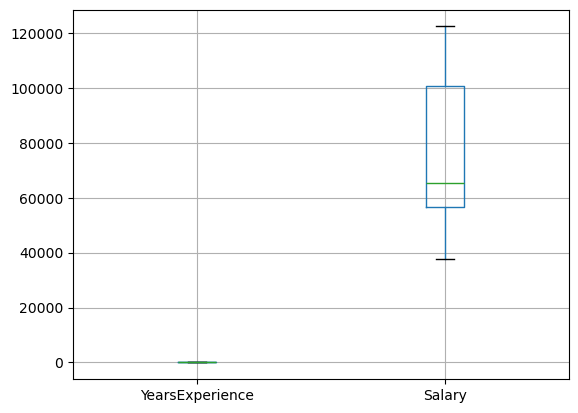

In [10]:
df.boxplot()

# Univariate Analysis

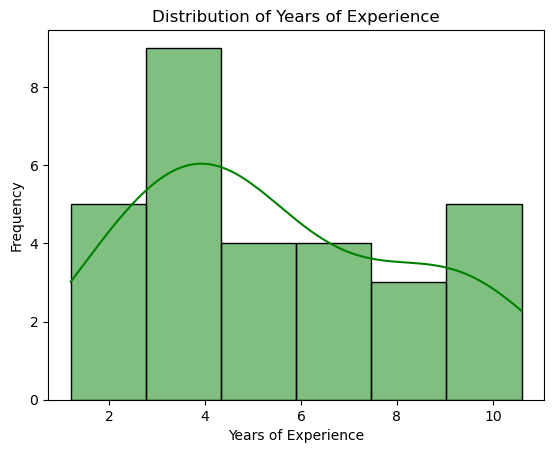

In [37]:
sns.histplot(df['YearsExperience'], kde=True, color='green')
plt.title('Distribution of Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Frequency')
plt.show()

# Bivariate Analysis
 - The scatter plot indicates a positive linear relationship between Years of Experience and Salary. Employees with more experience generally earn higher salaries, making YearsExperience a strong predictor of Salary.

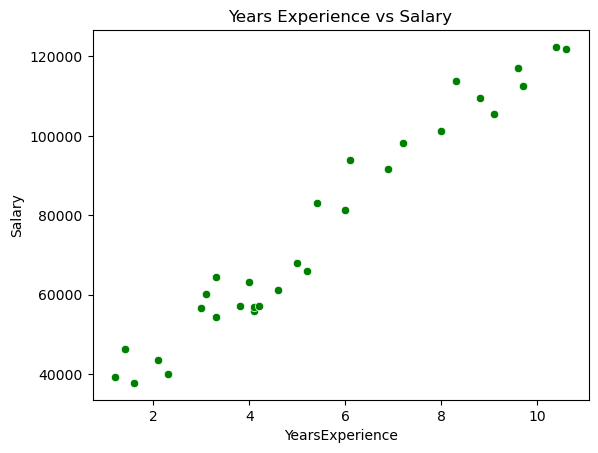

In [41]:
sns.scatterplot(x=df['YearsExperience'],y=df['Salary'],color='green')
plt.title('Years Experience vs Salary')
plt.show()

# Correlation Analysis

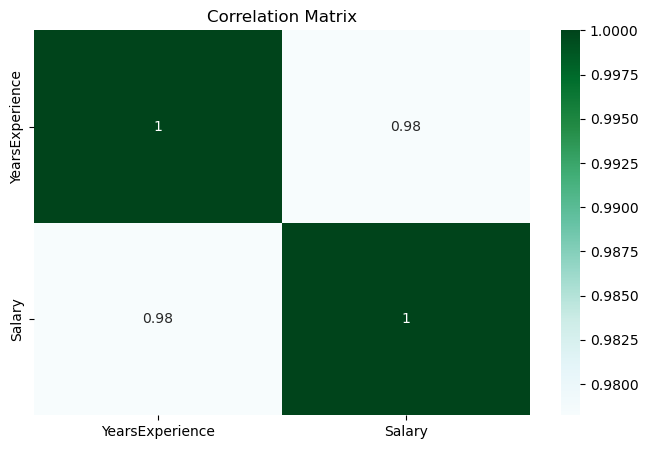

In [42]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='BuGn')
plt.title('Correlation Matrix')
plt.show()

# Feature Selection

In [43]:
X=df[['YearsExperience']] # independent variable
y=df['Salary'] # Target column

# Model Building

In [44]:
lr=LinearRegression()
lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
print(f"Coefficient value: {lr.coef_}")
print(f"Slope value: {lr.intercept_}")

Coefficient value: [9449.96232146]
Slope value: 24848.203966523222


# Prediction

In [17]:
ypred=lr.predict(X)
ypred

array([ 36188.15875227,  38078.15121656,  39968.14368085,  44693.12484158,
        46583.11730587,  53198.09093089,  54143.08716303,  56033.07962732,
        56033.07962732,  60758.06078805,  62648.05325234,  63593.04948449,
        63593.04948449,  64538.04571663,  68318.03064522,  72098.0155738 ,
        73988.00803809,  75878.00050238,  81547.97789525,  82492.9741274 ,
        90052.94398456,  92887.932681  , 100447.90253816, 103282.8912346 ,
       108007.87239533, 110842.86109176, 115567.84225249, 116512.83848464,
       123127.81210966, 125017.80457395])

# Evaluation metrics

In [18]:
mse=mean_squared_error(y,ypred)
mae=mean_absolute_error(y,ypred)
print(f"Mean_squared_error: {mse}")
print(f"Root_mean_squared_error: {np.sqrt(mse)}")
print(f"Mean_absolute_error: {mae}")
print(f"R2_score: {r2_score(y,ypred)}")

Mean_squared_error: 31270951.722280968
Root_mean_squared_error: 5592.043608760662
Mean_absolute_error: 4644.2012894435375
R2_score: 0.9569566641435086


# Visualization of Results

In [46]:
df['Predicted Salary']=ypred

In [47]:
df

,YearsExperience,Salary,Predicted Salary
0,1.2,39344.0,36188.158752
1,1.4,46206.0,38078.151217
2,1.6,37732.0,39968.143681
3,2.1,43526.0,44693.124842
4,2.3,39892.0,46583.117306
5,3.0,56643.0,53198.090931
6,3.1,60151.0,54143.087163
7,3.3,54446.0,56033.079627
8,3.3,64446.0,56033.079627
9,3.8,57190.0,60758.060788


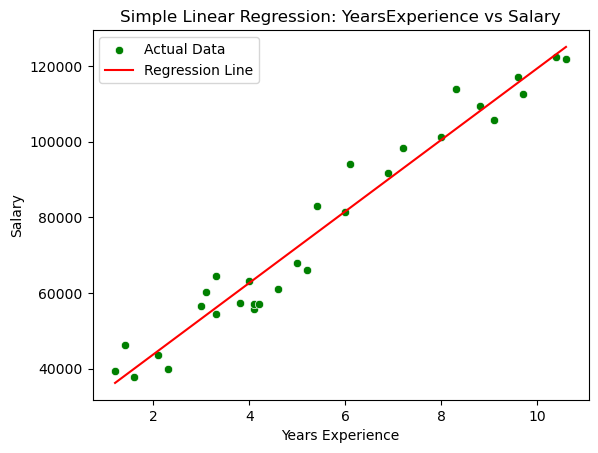

In [48]:
sns.scatterplot(
    x=df['YearsExperience'],
    y=df['Salary'],
    color='green',
    label='Actual Data'
)

sns.lineplot(
    x=df['YearsExperience'],
    y=ypred,
    color='red',
    label='Regression Line'
)

plt.title('Simple Linear Regression: YearsExperience vs Salary')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

# Final Model

In [49]:
print("╔══════════════════════════════════════════════╗")
print("║       FINAL MODEL PERFORMANCE SUMMARY        ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  R² Score              : {r2_score(y, ypred)*100:>7.2f}%            ║")
print(f"║  MAE                   : {mae:>10.2f}          ║")
print(f"║  RMSE                  : {np.sqrt(mse):>10.2f}          ║")
print(f"║  Features Used         : {X.shape[1]:>10}          ║")
print("╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║       FINAL MODEL PERFORMANCE SUMMARY        ║
╠══════════════════════════════════════════════╣
║  R² Score              :   95.70%            ║
║  MAE                   :    4644.20          ║
║  RMSE                  :    5592.04          ║
║  Features Used         :          1          ║
╚══════════════════════════════════════════════╝


# Conclusion
 - The Simple Linear Regression model performed well with an R² Score of 95.7%, demonstrating a strong relationship between Years of Experience and Salary. The low prediction errors and high explanatory power indicate that Years of Experience is a significant predictor of Salary